In [1]:
import os
import re
import pandas as pd
import nilearn as nl
import numpy as np
import seaborn as sns
from nilearn.input_data import NiftiMasker
from nilearn.image.image import mean_img
from nilearn import plotting, image
from nilearn.plotting import view_img
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


/home/strange/.local/lib/python3.7/site-packages/nilearn/datasets/__init__.py:90: FutureWarning: Fetchers from the nilearn.datasets module will be updated in version 0.9 to return python strings instead of bytes and Pandas dataframes instead of Numpy arrays.
  "Numpy arrays.", FutureWarning)


['../derivatives/fmriprep/sub-2001/func/sub-2001_task-sharedreward_acq-mb3me4_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz',
 '../derivatives/fmriprep/sub-2001/func/sub-2001_task-sharedreward_acq-mb6me4_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz',
 '../derivatives/fmriprep/sub-2001/func/sub-2001_task-sharedreward_acq-mb1me4_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz',
 '../derivatives/fmriprep/sub-2001/func/sub-2001_task-sharedreward_acq-mb6me1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz',
 '../derivatives/fmriprep/sub-2001/func/sub-2001_task-sharedreward_acq-mb3me1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz',
 '../derivatives/fmriprep/sub-2001/func/sub-2001_task-sharedreward_acq-mb1me1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz']

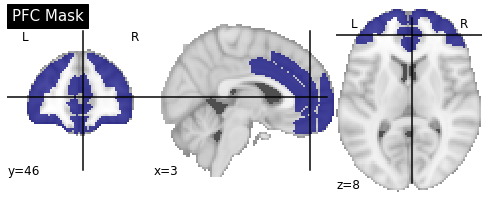

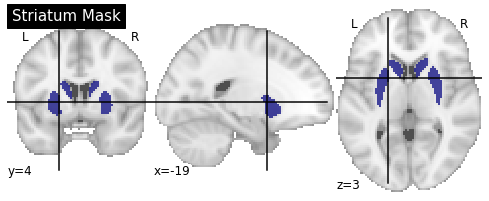

In [2]:
from nilearn import image,datasets,masking,plotting,input_data
#Striatum Mask

f_list = [os.path.join(root,f) for root,dirs,files in os.walk(
    '../derivatives/') for f in files if f.endswith('desc-preproc_bold.nii.gz')]
display(f_list)

HO_sub=datasets.fetch_atlas_harvard_oxford(atlas_name='sub-maxprob-thr50-2mm')

keep = [idx for idx, s in enumerate(HO_sub.labels) if
        'Accumbens' in s or
        'Caudate' in s or
        'Putamen' in s]

keepimg_list=[image.math_img("img==%s"%(idx),img=HO_sub.maps) for idx in keep]   
str_regions=image.concat_imgs(np.array(keepimg_list))

str_mask=masking.compute_background_mask(str_regions)
str_mask=NiftiMasker(mask_img=str_mask)

#MPFC mask
HO_cort=datasets.fetch_atlas_harvard_oxford(atlas_name='cort-maxprob-thr50-2mm')
keep = [idx for idx, s in enumerate(HO_cort.labels) if
        'Frontal Medial Cortex'==s or
        'Frontal Pole'==s or
        'Frontal Orbital Cortex'==s or
        'Cingulate Gyrus, anterior division'==s or
        'Paracingulate Gyrus'==s]

keepimg_list=[image.math_img("img==%s"%(idx),img=HO_cort.maps) for idx in keep]                               
cort_regions=image.concat_imgs(np.array(keepimg_list))

cort_mask=masking.compute_background_mask(cort_regions)

cort_mask=NiftiMasker(mask_img=cort_mask)

plotting.plot_roi(cort_mask.mask_img,title="PFC Mask")
plt.show()
plotting.plot_roi(str_mask.mask_img,title='Striatum Mask')
plt.show()

In [3]:
data=[]
img_list=[]
for img in f_list:

    me=int(re.search('_acq-mb[0-7]me(.*?)_',img).group(1))
    mb=int(re.search('_acq-mb(.*?)me',img).group(1))
    sub=re.search('sub-(.*?)_task',img).group(1)
    mask = re.sub("desc-(.*?).nii.gz","desc-brain_mask.nii.gz",img)
    
    nifti_masker = NiftiMasker(mask_img=mask)
    x=nifti_masker.fit_transform(img)
    img=nifti_masker.inverse_transform(x)
    
    
    # calculate mean image for the background
    from nilearn.image import math_img
    tsnr_img = image.math_img('img.mean(axis=3) / img.std(axis=3)', img=img)
    img_list.append([tsnr_img,me,mb])
    x=nifti_masker.fit_transform(tsnr_img)
    y=str_mask.fit_transform(tsnr_img)
    z=cort_mask.fit_transform(tsnr_img)
    data.append([sub,mb,me,np.mean(np.abs(x.flatten())),
                 np.mean(np.abs(y.flatten())),
                 np.mean(np.abs(z.flatten()))])

# Heads up these Graphs are interactive


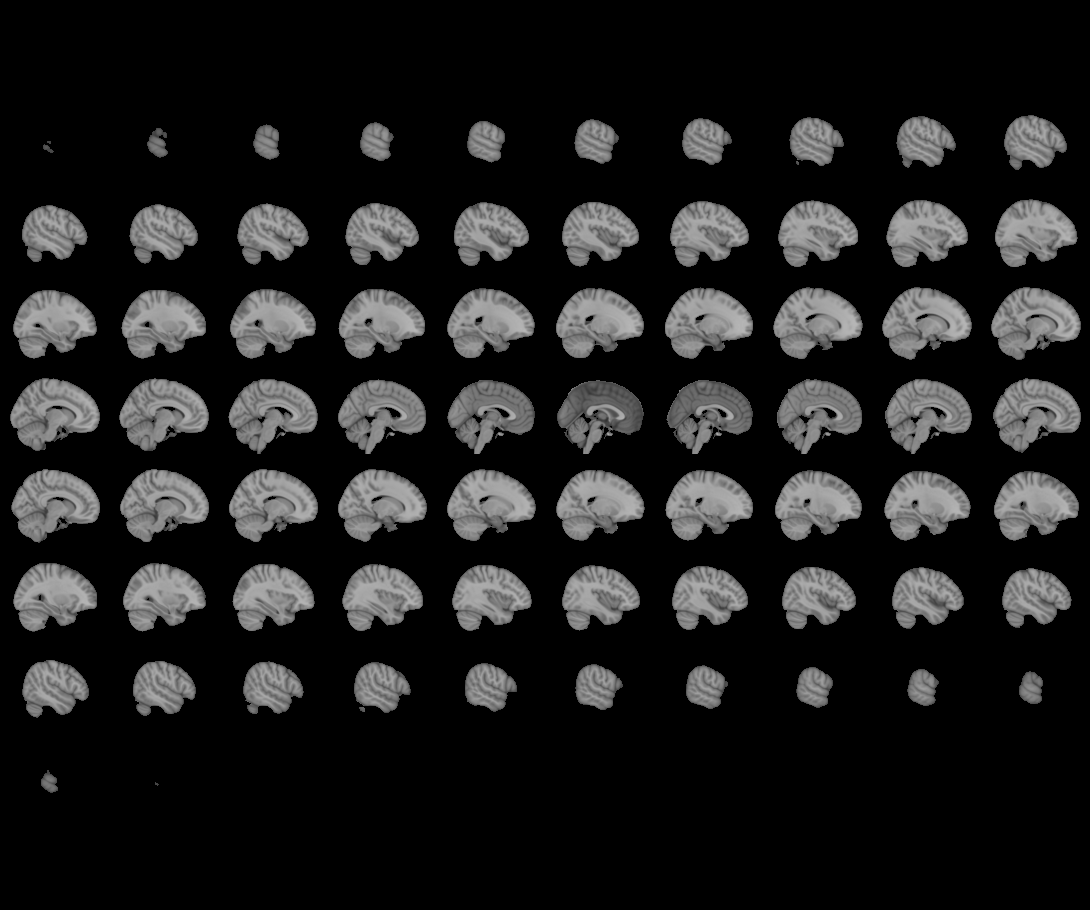
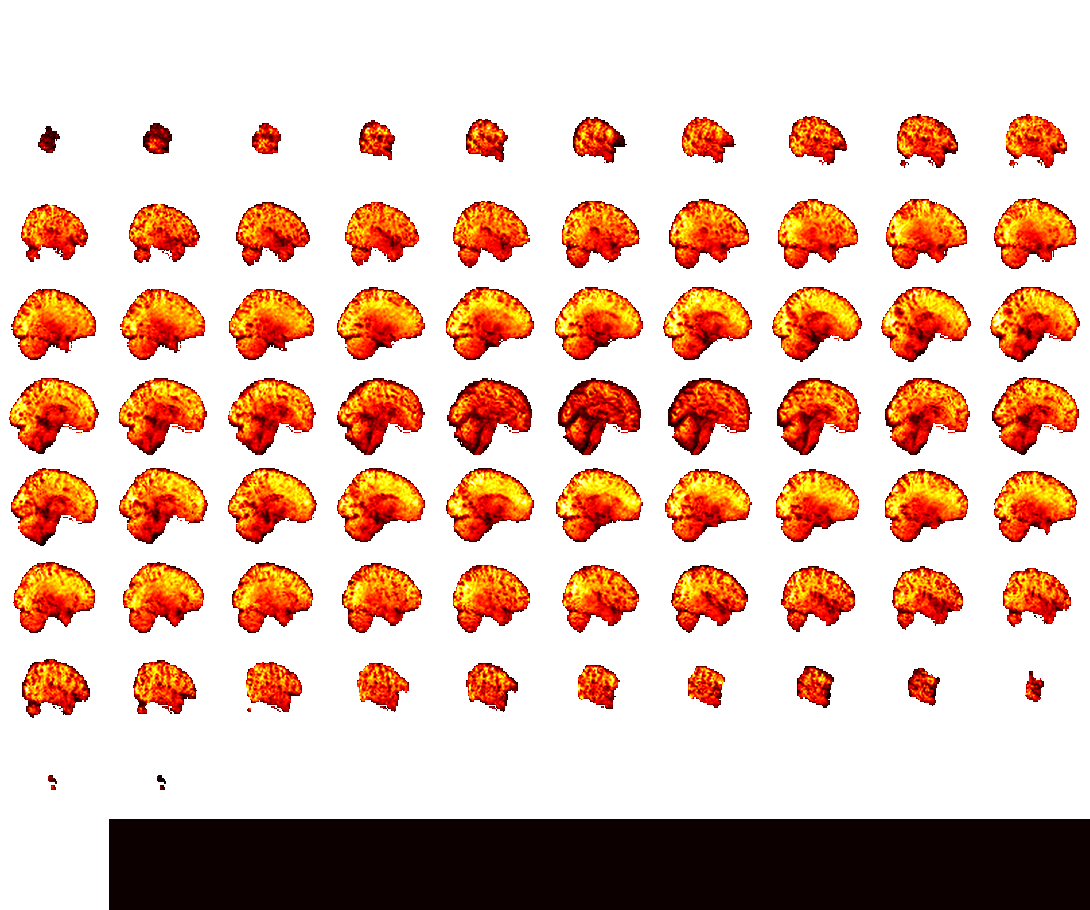

In [4]:
plotting.view_img(img_list[0][0],
                  title="tsnr for ME: %s MB: %s "%(img_list[0][1],img_list[0][2]),
                  vmax=200,draw_cross=False)



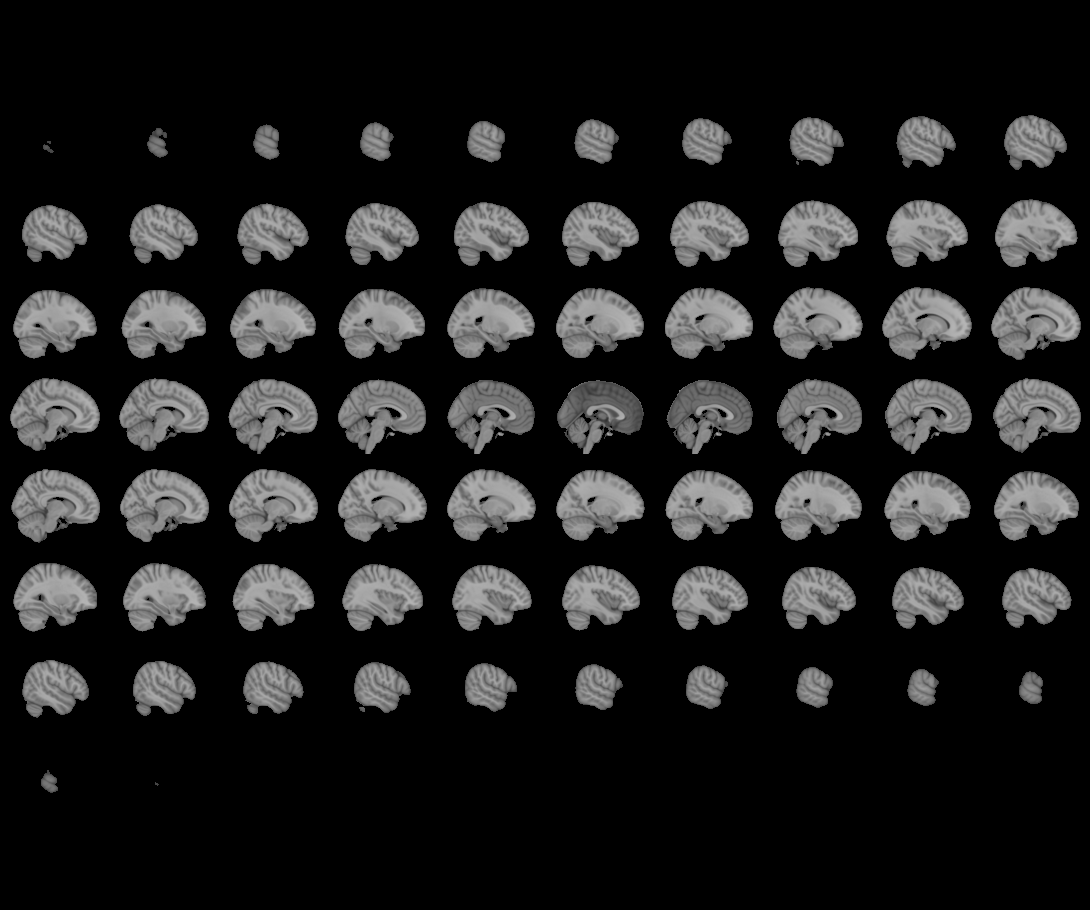
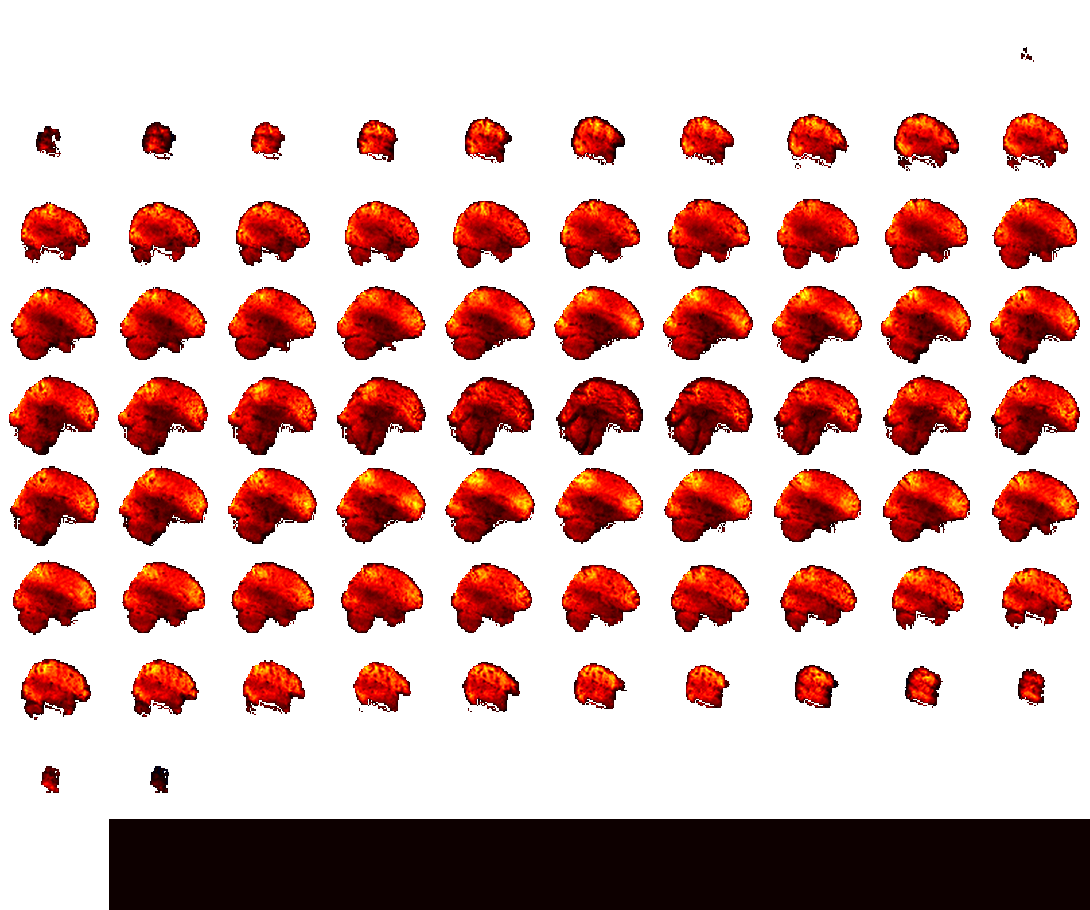

In [5]:
plotting.view_img(img_list[1][0],
                  title="tsnr for ME: %s MB: %s "%(img_list[1][1],img_list[1][2]),
                  vmax=200,draw_cross=False)


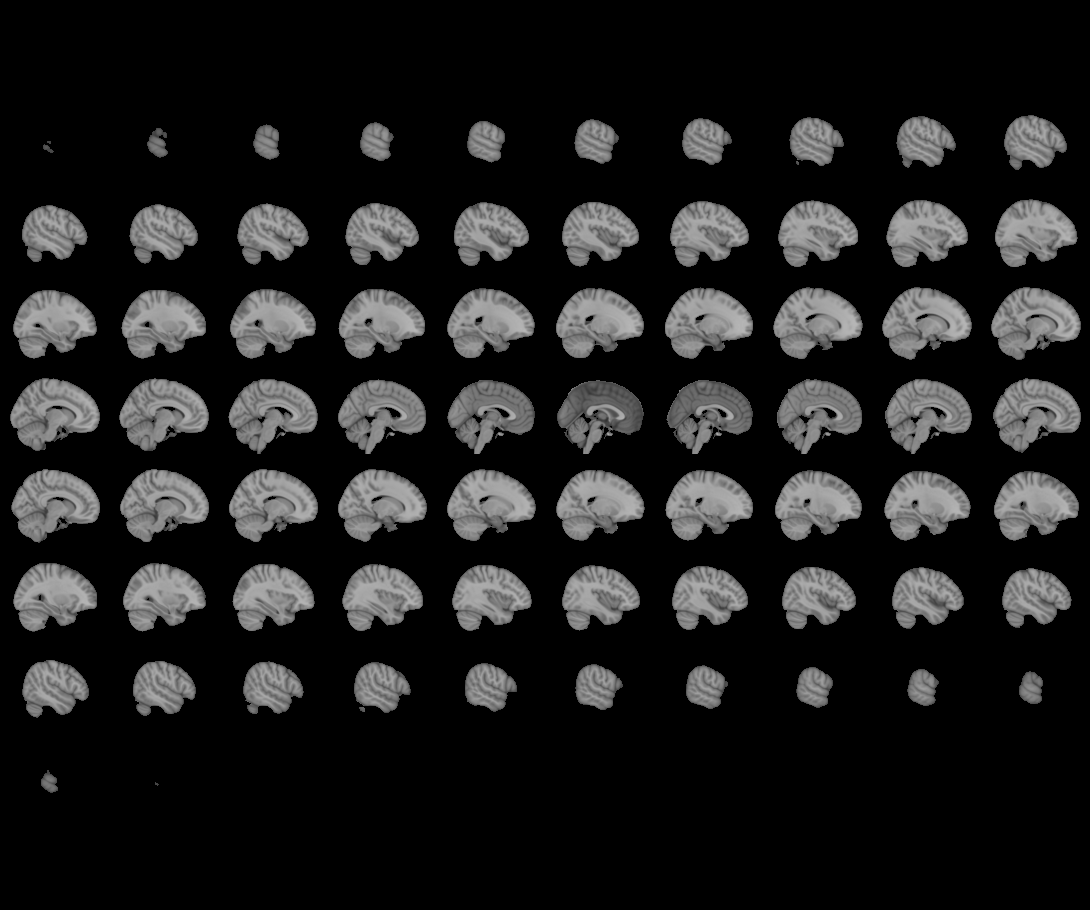
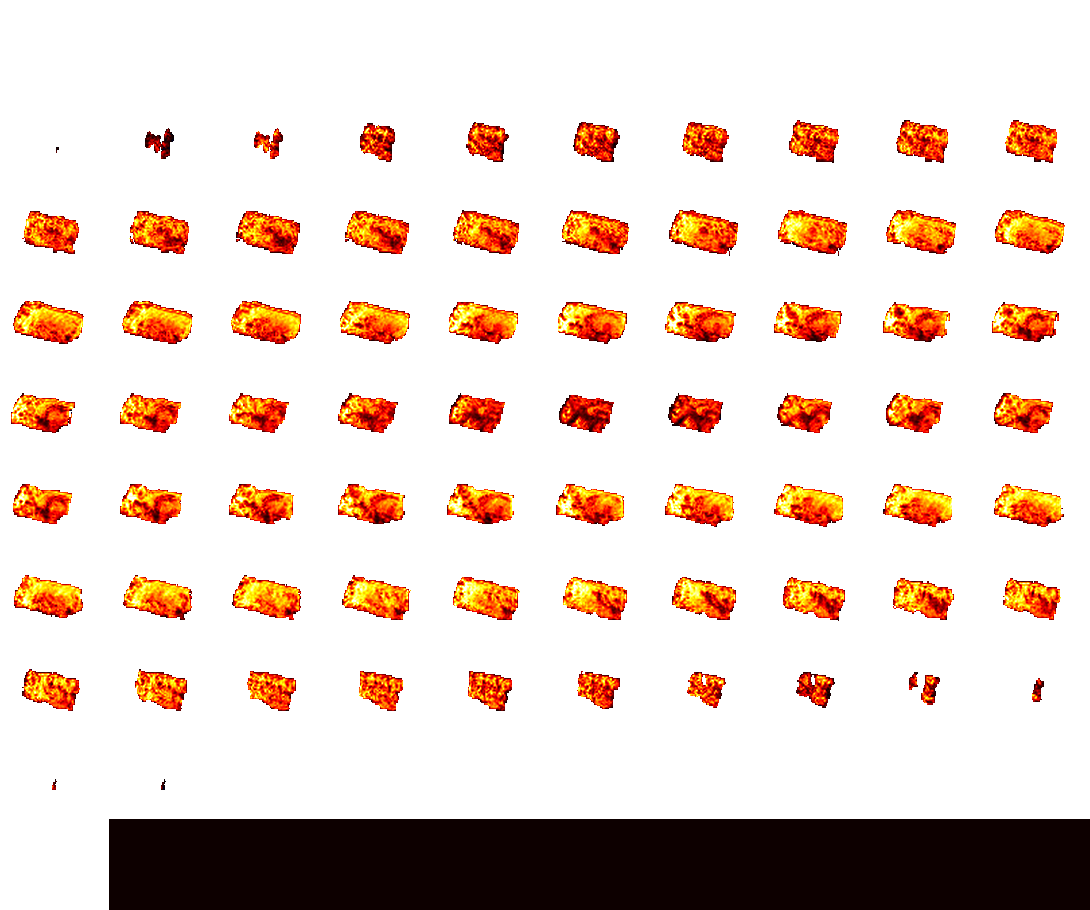

In [6]:
plotting.view_img(img_list[2][0],
                  title="tsnr for ME: %s MB: %s "%(img_list[2][1],img_list[2][2]),
                  vmax=200,draw_cross=False)


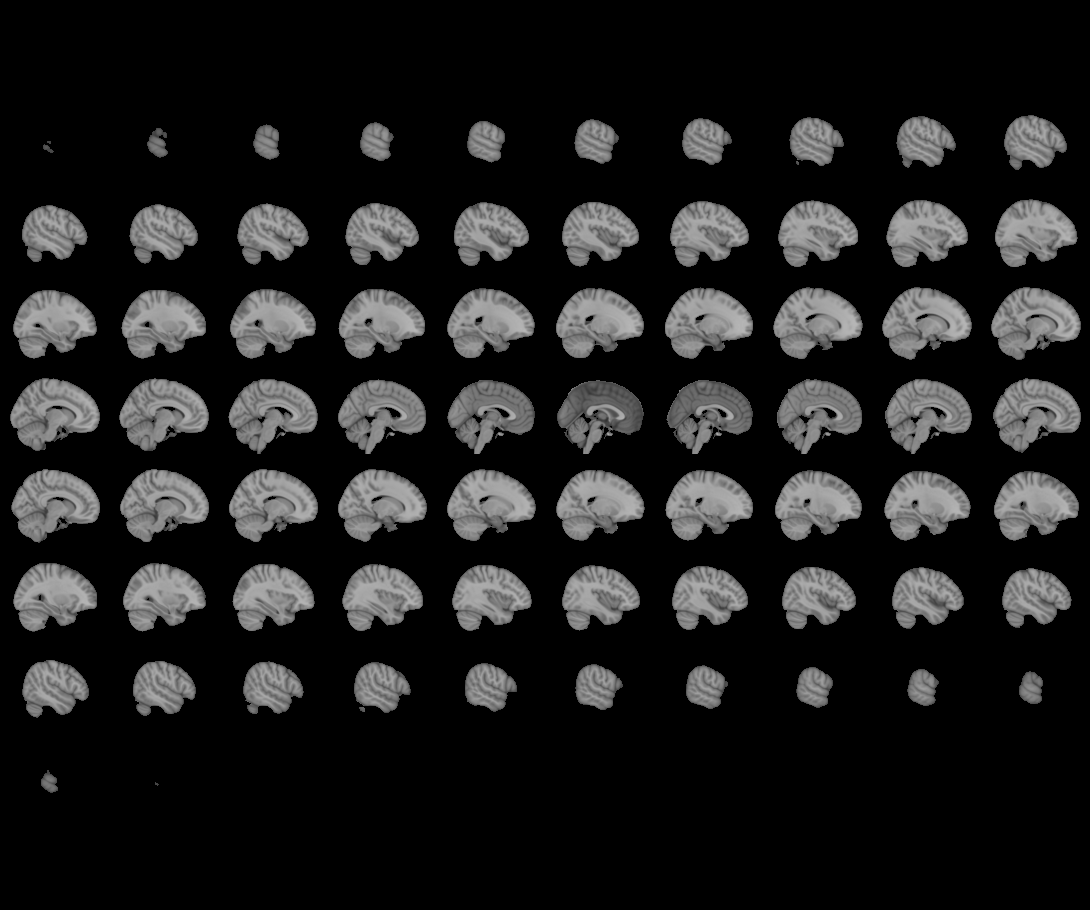
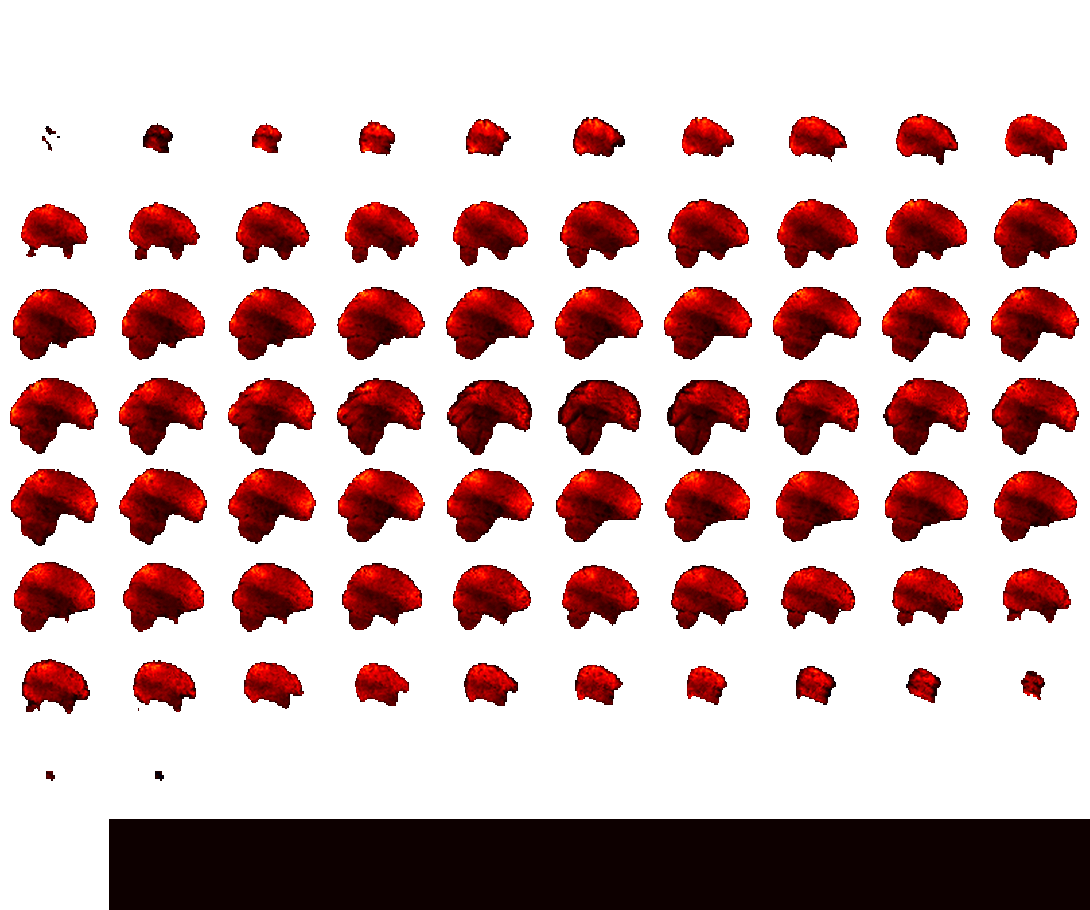

In [7]:
plotting.view_img(img_list[3][0],
                  title="tsnr for ME: %s MB: %s "%(img_list[3][1],img_list[3][2]),
                  vmax=200,draw_cross=False)


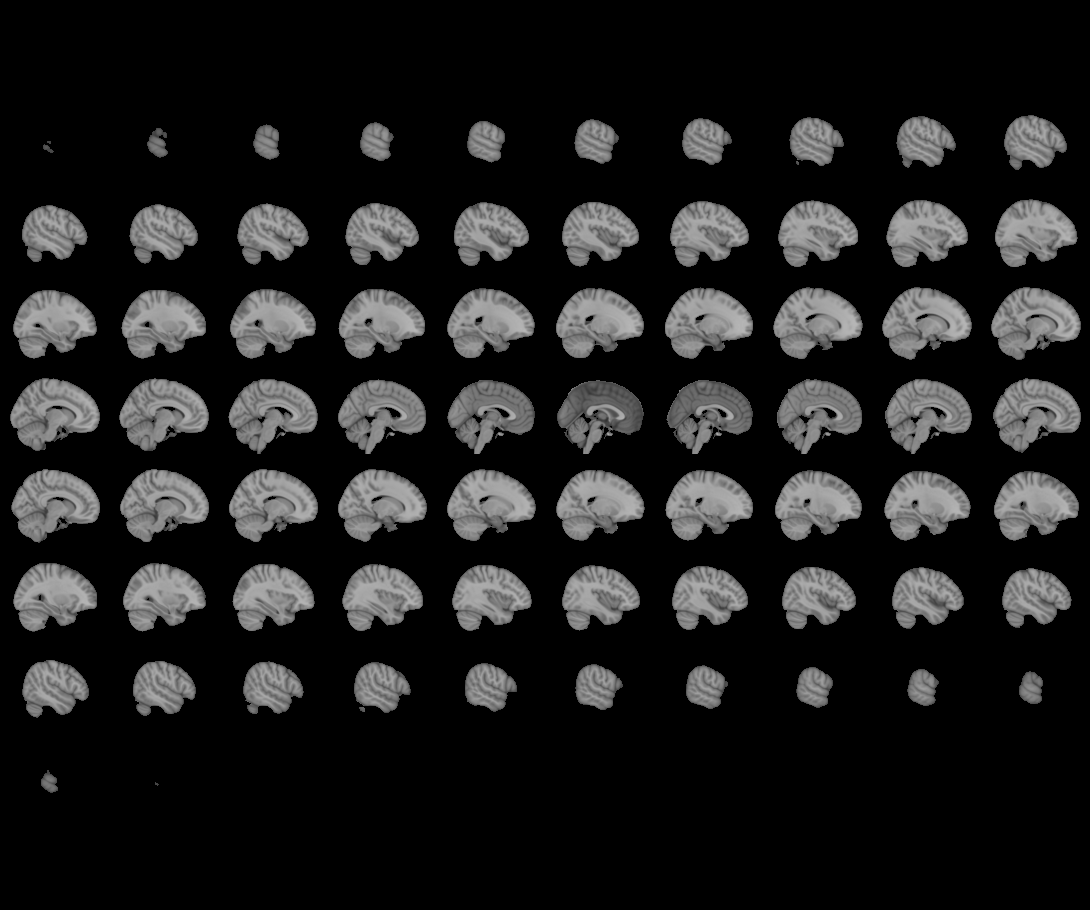
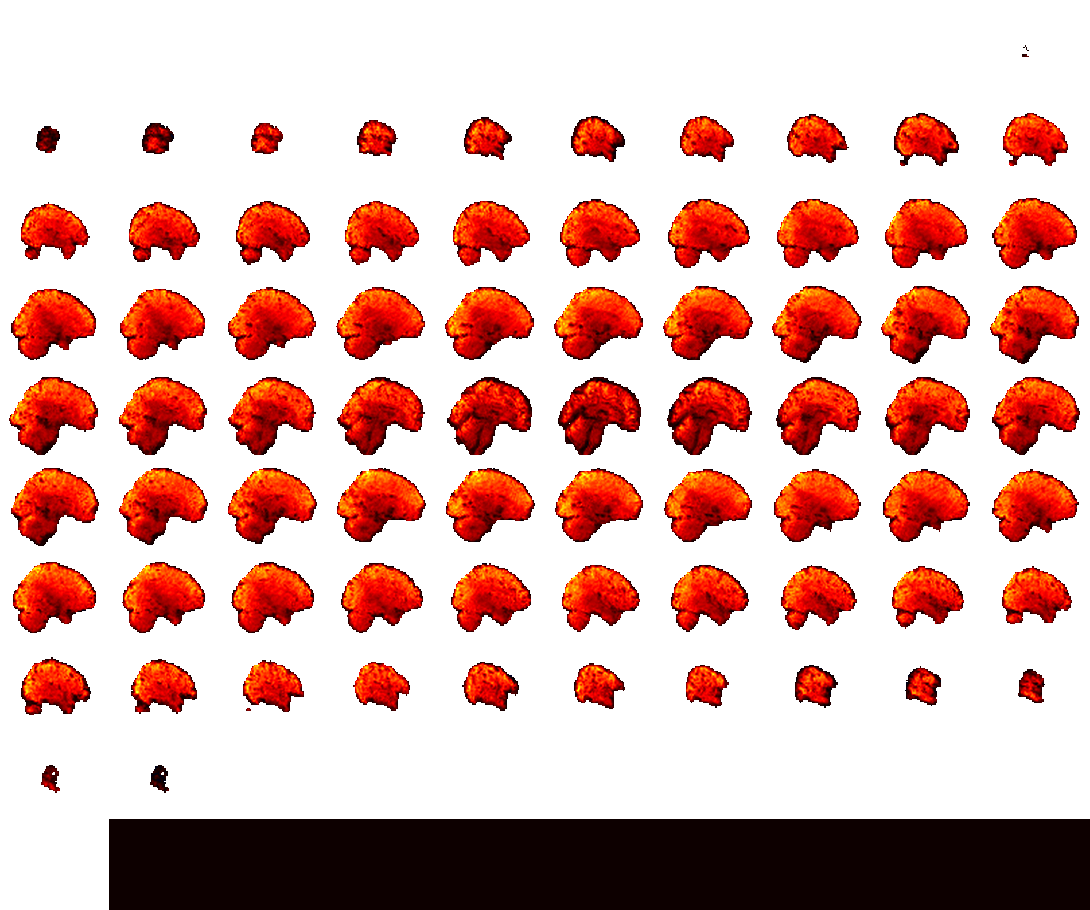

In [8]:
plotting.view_img(img_list[4][0],
                  title="tsnr for ME: %s MB: %s "%(img_list[4][1],img_list[4][2]),
                  vmax=200,draw_cross=False)


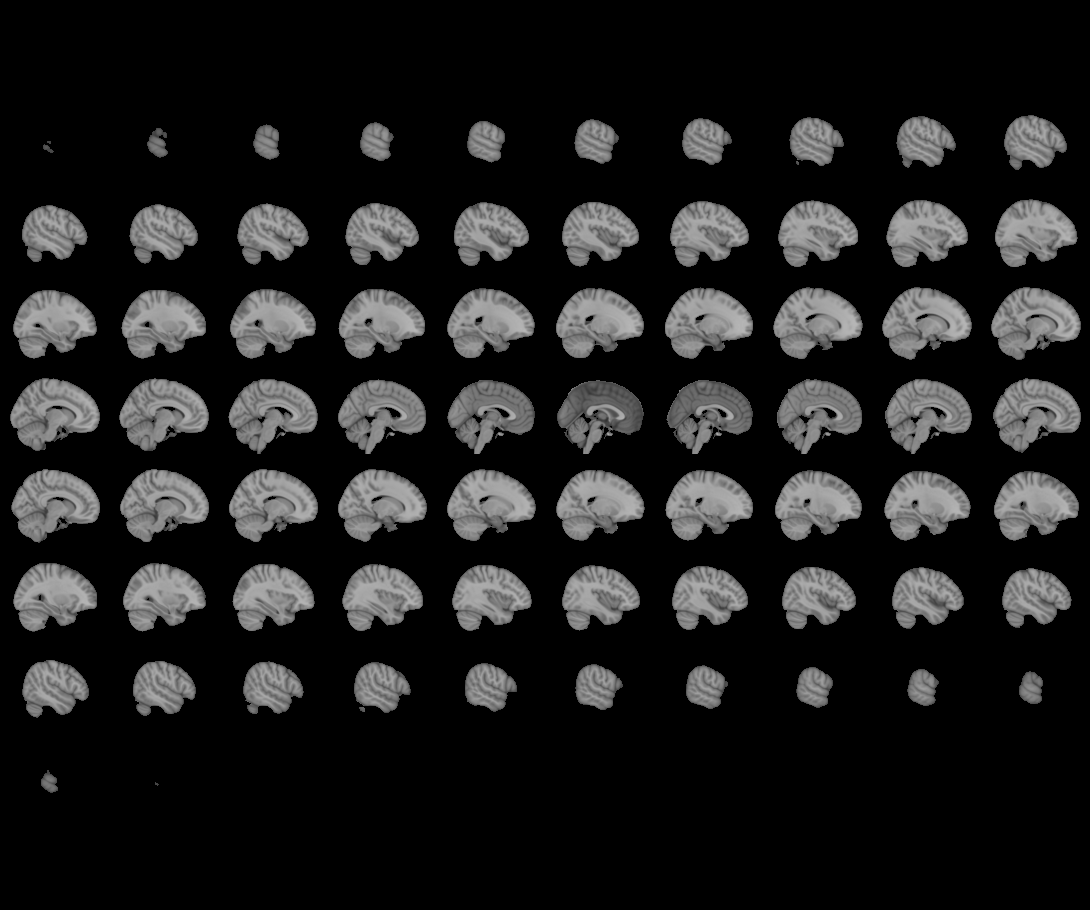
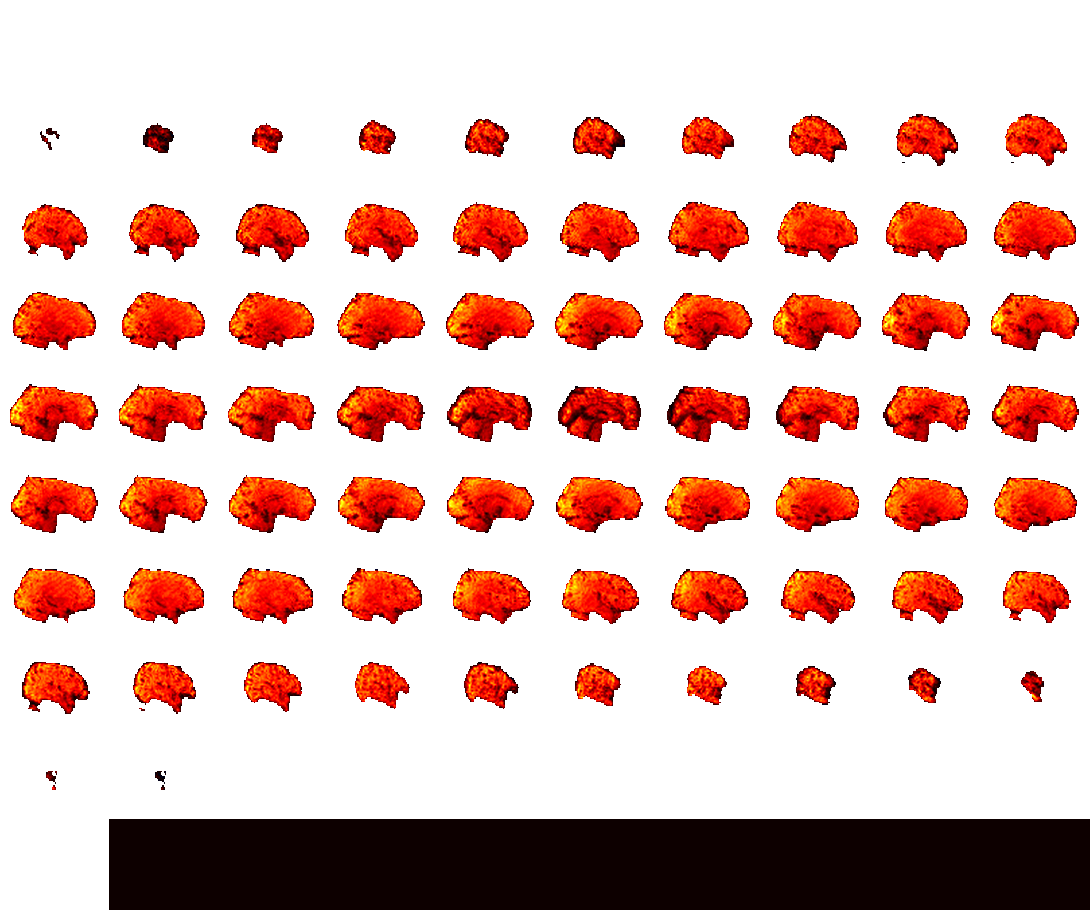

In [9]:
plotting.view_img(img_list[5][0],
                  title="tsnr for ME: %s MB: %s "%(img_list[5][1],img_list[5][2]),
                  vmax=200,draw_cross=False)

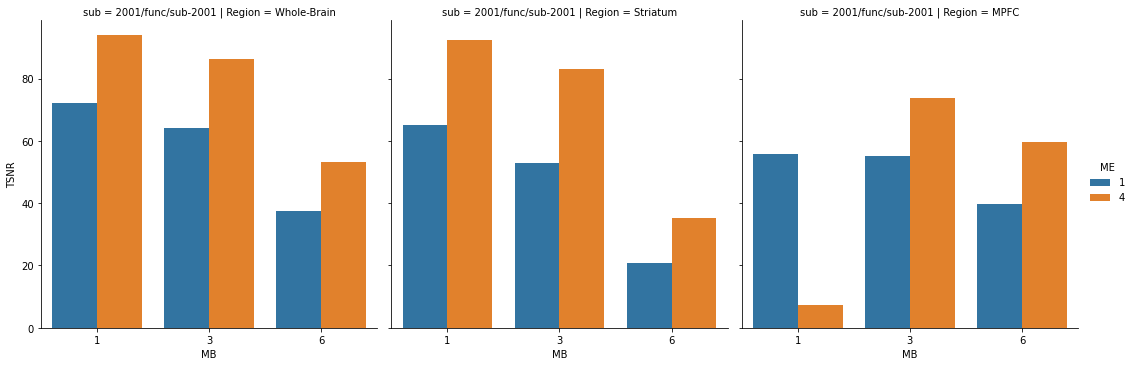

In [10]:

df=pd.DataFrame(data=data,columns=['sub','MB','ME','Whole-Brain','Striatum','MPFC'])
df=df.melt(id_vars=['sub','MB','ME'],var_name='Region',value_name='TSNR')
g=sns.catplot(x='MB',y='TSNR',hue='ME',data=df,col='Region',row='sub',kind='bar')
g.savefig('RF1-1subs_2regions.pdf')